In [8]:
import numpy as np
import xarray as xr
import xclimate as xclim

In [56]:
# client_cluster = xclim.create_dask_cluster(
#     account='UWAS0155',
#     nworkers=4,
#     ncores=1,
#     nmem='15GB',
#     walltime='02:00:00',
# )

In [57]:
# client_cluster[0].restart()

In [58]:
# xclim.close_dask_cluster(client_cluster)

In [59]:
def compute_esat_goff_gratch(temp_K):
    """Saturation vapor pressure from Goff-Gratch equation (1945)"""
    # Constants
    temp_smpt = 373.16  # [K] steam-point (boiling point at 1 atm)
    es_smpt = 101_325   # [Pa] steam-point pressure

    # Compute saturation vapor pressure using Goff-Gratch (1945) equation
    es = es_smpt * 10.0 ** (
        -7.90298 * (temp_smpt / temp_K - 1.0)
        + 5.02808 * np.log10(temp_smpt)
        - 1.3816e-7 * (10.0 ** (11.344 * (1.0 - temp_K / temp_smpt)) - 1.0)
        + 8.1328e-3 * (10.0 ** (-3.49149 * (temp_smpt / temp_K - 1.0)) - 1.0)
    )
    return es


def compute_esat_empirical(temp_C):
    """Saturation vapor pressure from empirical form in Schefff & Frierson (2014)."""
    return 610.8 * np.exp((17.27 * temp_C) / (temp_C + 273.15))

In [ ]:
def compute_esat_empirical(temp_C):
    """Saturation vapor pressure from empirical form in Schefff & Frierson (2014)."""
    return 610.8 * np.exp((17.27 * temp_C) / (temp_C + 273.15))

def calc_pm_pet(SH, LH, T_a, RH, U, P_s):
    """
    SH : np.ndarray
        Sensible heat flux [W m-2]
    LH : np.ndarray
        Latent heat flux [W m-2]
    T_a : np.ndarray
        Near-surface air temperature [K]
    RH : np.ndarray
        Near-surface relative humidity [1]
    U : np.ndarray
        Near-surface wind speed [m s-1]
    P_s : np.ndarray
        Surface pressure [Pa]

    Scheff, J., & Frierson, D. M. W. (2014). Scaling Potential
    Evapotranspirationwith Greenhouse Warming. Journal of Climate,
    27(4), 1539-1558. https://doi.org/10.1175/JCLI-D-13-00233.1
    """

    # Constants
    L_v = 2.45e6     # [J kg-1]
    r_s = 40         # [s m-1], set to match Cook et al. (2014)
    epsilon = 0.622  # [1]
    c_p = 4182       # [J kg-1 K-1]
    R_v = 461        # [J kg-1 K-1]

    # Drag coefficient constants
    k = 0.41           # [1]
    h = 0.5            # [m], assumed vegetation height for alfalfa
    z_w = 10           # [m]
    z_h = 2            # [m]
    z_om = 0.123 * h   # [m]
    z_oh = 0.0123 * h  # [m]
    d = 0              # [m]

    C_H = (k * k) / (np.log((z_w - d) / z_om) * np.log((z_h - d) / z_oh))

    rho_a = 1.01 * P_s / R_v / T_a
    gamma = P_s * c_p / epsilon / L_v
    e_sat = compute_esat_empirical(T_a - 273.15)
    delta = L_v * e_sat / R_v / T_a / T_a

    numerator = (delta * (SH + LH)) + (rho_a * c_p * e_sat * (1 - RH) * C_H * U)
    denominator = delta + gamma * (1 + r_s * C_H * U)
    pet = numerator / denominator

    if isinstance(pet, xr.DataArray):
        pet = pet.rename("PET")
        pet.attrs = {
            "long_name": "Penman-Monteith potential evapotranspiration",
            "units": "W/m2",
        }

    return pet

In [47]:
tperiod = slice('1995-01', '2014-12')
grid = xclim.load_fhist_ppe_grid().compute()

In [61]:
variable_names = [
    "EFLX_LH_TOT", "FSH", "PS", "TSA", "RH2M", "U10", "FSNO",
]
freq = "month"

# Load variables
fhist = {}
variables = []
for v in variable_names:
    print(v)
    key = f"{v}_{freq}_1"
    fhist[key] = (
        xclim.load_fhist(key, keep_var_only=True)[v]
        .sel(time=tperiod)
        .reindex_like(grid, method="nearest", tolerance=1e-3)
        .chunk({'time': -1})
        .persist()
    )
    variables.append(key)

# Rename ET
fhist[f"ET_{freq}_1"] = fhist[f"EFLX_LH_TOT_{freq}_1"]
fhist.pop(f"EFLX_LH_TOT_{freq}_1");

EFLX_LH_TOT
FSH
PS
TSA
RH2M
U10
FSNO


In [62]:
snow_pct_threshold = 80 / 100  # maximum allowable percent of snow cover on all months of the average year
nonglc_pct_threshold = 80      # maximum allowable percent of glaciated land for a NON-glaciated gridcell

fhist["FSNO_clim"] = fhist["FSNO_month_1"].weighted(fhist["FSNO_month_1"].time.dt.days_in_month).mean("time")
snow_mask = xr.where(fhist["FSNO_clim"] > snow_pct_threshold, 0, 1)

nonglc_mask = grid.PCT_GLC < nonglc_pct_threshold
all_mask = snow_mask & nonglc_mask & (grid.LANDFRAC > 0)

In [64]:
fhist_masked = {}
fhist_masked = {}
for name, da in fhist.items():
    fhist_masked[name] = fhist[name].where(all_mask)

In [98]:
m = 0

pet = calc_pm_pet(
    SH=fhist_masked["FSH_month_1"].sel(member=m),
    LH=fhist_masked["ET_month_1"].sel(member=m),
    T_a=fhist_masked["TSA_month_1"].sel(member=m),
    RH=fhist_masked["RH2M_month_1"].sel(member=m) / 100,
    U=fhist_masked["U10_month_1"].sel(member=m),
    P_s=fhist_masked["PS_month_1"].sel(member=m),
).compute()

pet = pet.clip(min=0)  # floor at 0 --> PET as demand for water

In [99]:
pet

<xarray.DataArray 'PET' (time: 240, lat: 96, lon: 144)> Size: 27MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(240, 96, 144))
Coordinates:
  * time      (time) object 2kB 1995-01-01 00:00:00 ... 2014-12-01 00:00:00
  * lat       (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon       (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
    member    int64 8B 0
    ltype     int64 8B 4
    landunit  <U40 160B 'ltype_landice_multiple_elevation_classes'
Attributes:
    long_name:  Penman-Monteith potential evapotranspiration
    units:      W/m2

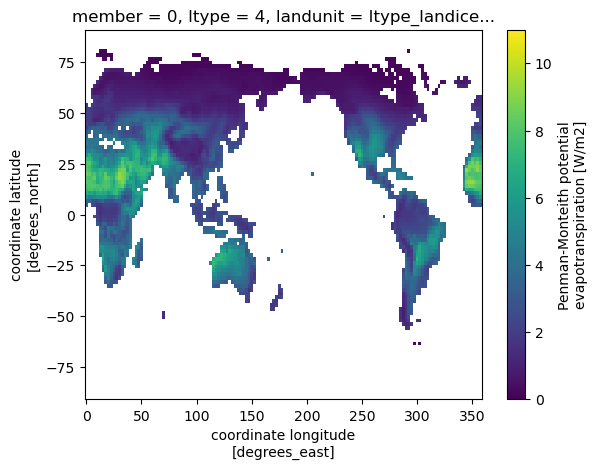

In [100]:
(pet.weighted(pet.time.dt.days_in_month).mean(dim='time') * 12.6 / 365).plot(vmin=0, vmax=11)